In [ ]:
import pandas as pd
import nltk
import string
import joblib
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import linear_kernel
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Load the necessary NLTK resources
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...


True

In [ ]:

# IMPORTANT: RUN THIS CELL IN ORDER TO IMPORT YOUR KAGGLE DATA SOURCES
# TO THE CORRECT LOCATION (/kaggle/input) IN YOUR NOTEBOOK,
# THEN FEEL FREE TO DELETE THIS CELL.
# NOTE: THIS NOTEBOOK ENVIRONMENT DIFFERS FROM KAGGLE'S PYTHON
# ENVIRONMENT SO THERE MAY BE MISSING LIBRARIES USED BY YOUR
# NOTEBOOK.

import os
import sys
from tempfile import NamedTemporaryFile
from urllib.request import urlopen
from urllib.parse import unquote, urlparse
from urllib.error import HTTPError
from zipfile import ZipFile
import tarfile
import shutil

CHUNK_SIZE = 40960
DATA_SOURCE_MAPPING = 'food-com-recipes-and-user-interactions:https%3A%2F%2Fstorage.googleapis.com%2Fkaggle-data-sets%2F311962%2F783630%2Fbundle%2Farchive.zip%3FX-Goog-Algorithm%3DGOOG4-RSA-SHA256%26X-Goog-Credential%3Dgcp-kaggle-com%2540kaggle-161607.iam.gserviceaccount.com%252F20240901%252Fauto%252Fstorage%252Fgoog4_request%26X-Goog-Date%3D20240901T195816Z%26X-Goog-Expires%3D259200%26X-Goog-SignedHeaders%3Dhost%26X-Goog-Signature%3D6d12918a8bec8e3e5dd5fbf808c3f791973fbf97a5fee3cab111e28814022ec535361b6aa81ec8a788e8c50010cb495aed1eee3f639a2aaae5263b28afa4f1d1e634cc81a8f0ac1e2ee7f9c0d6ac7ce5e3cf6b5a185f090dfb36d04dee8c7bd6b271ea5b3eaf4e0e5cfcae8dc1afb3e5bf6220e3a19e3b8d2cc3880ba57f8bcaf77c3a95e8d124b603de210755ddc1d769cba6137590e44c75cb8720cf4a1d604d9b7968c03b5a6ddf9c9ccc9e58c22457d2c0b38fcf387702051e592ee2fa01e063f8f5d4fa68b9892e87023bcbb00ba8b89a36dd55f8a071a55dd2c1ad04553c15185e1de1e2746eaa0e2c924738ca01c6b5ec76f2930a6c83272a3df163ff'

KAGGLE_INPUT_PATH='/kaggle/input'
KAGGLE_WORKING_PATH='/kaggle/working'
KAGGLE_SYMLINK='kaggle'

!umount /kaggle/input/ 2> /dev/null
shutil.rmtree('/kaggle/input', ignore_errors=True)
os.makedirs(KAGGLE_INPUT_PATH, 0o777, exist_ok=True)
os.makedirs(KAGGLE_WORKING_PATH, 0o777, exist_ok=True)

try:
  os.symlink(KAGGLE_INPUT_PATH, os.path.join("..", 'input'), target_is_directory=True)
except FileExistsError:
  pass
try:
  os.symlink(KAGGLE_WORKING_PATH, os.path.join("..", 'working'), target_is_directory=True)
except FileExistsError:
  pass

for data_source_mapping in DATA_SOURCE_MAPPING.split(','):
    directory, download_url_encoded = data_source_mapping.split(':')
    download_url = unquote(download_url_encoded)
    filename = urlparse(download_url).path
    destination_path = os.path.join(KAGGLE_INPUT_PATH, directory)
    try:
        with urlopen(download_url) as fileres, NamedTemporaryFile() as tfile:
            total_length = fileres.headers['content-length']
            print(f'Downloading {directory}, {total_length} bytes compressed')
            dl = 0
            data = fileres.read(CHUNK_SIZE)
            while len(data) > 0:
                dl += len(data)
                tfile.write(data)
                done = int(50 * dl / int(total_length))
                sys.stdout.write(f"\r[{'=' * done}{' ' * (50-done)}] {dl} bytes downloaded")
                sys.stdout.flush()
                data = fileres.read(CHUNK_SIZE)
            if filename.endswith('.zip'):
              with ZipFile(tfile) as zfile:
                zfile.extractall(destination_path)
            else:
              with tarfile.open(tfile.name) as tarfile:
                tarfile.extractall(destination_path)
            print(f'\nDownloaded and uncompressed: {directory}')
    except HTTPError as e:
        print(f'Failed to load (likely expired) {download_url} to path {destination_path}')
        continue
    except OSError as e:
        print(f'Failed to load {download_url} to path {destination_path}')
        continue

print('Data source import complete.')

[==================================================] 280350373 bytes downloaded
Downloaded and uncompressed: food-com-recipes-and-user-interactions
Data source import complete.


In [ ]:
# Drop columns that are not needed
# recipes_df = recipes_df.drop(columns=['id', 'contributor_id', 'submitted'])

In [ ]:
recipes_df=pd.read_csv("/content/drive/MyDrive/ml_Store/meal_plan_data.csv")

In [ ]:
#recipes_df = recipes_df.sample(3500).reset_index(drop=True)

In [ ]:
recipes_df.columns

Index(['name', 'minutes', 'tags', 'nutrition', 'n_steps', 'steps',
       'description', 'ingredients', 'n_ingredients', 'ingredients_cleaned',
       'tags_cleaned', 'description_cleaned', 'ingredients_stemmed',
       'tags_stemmed', 'description_stemmed', 'ingredients_lemmatized',
       'tags_lemmatized', 'description_lemmatized', 'soup'],
      dtype='object')

In [ ]:
data = recipes_df.drop(columns=['ingredients_cleaned',
       'tags_cleaned', 'description_cleaned', 'ingredients_stemmed',
       'tags_stemmed', 'description_stemmed', 'ingredients_lemmatized',
       'tags_lemmatized', 'description_lemmatized', 'soup'])

In [ ]:
recipes_df = pd.read_csv('/content/drive/MyDrive/ml_Store/data_meal.csv')

In [ ]:
recipes_df = recipes_df.sample(1500).reset_index(drop=True)

In [ ]:
data.to_csv('/content/drive/MyDrive/ml_Store/data_meal.csv', index=False)

In [ ]:
data.head()

,name,minutes,tags,nutrition,n_steps,steps,description,ingredients,n_ingredients
0,stan s tartar sauce,10,"['15-minutes-or-less', 'time-to-make', 'course...","[117.9, 15.0, 8.0, 12.0, 0.0, 7.0, 2.0]",2,"['mix all ingredients', 'chill']",this recipe came from my brother-in-law who us...,"['mayonnaise', 'dill pickle', 'green onions', ...",10
1,double shot mocha chunk cookies,30,"['30-minutes-or-less', 'time-to-make', 'course...","[130.9, 9.0, 47.0, 1.0, 3.0, 18.0, 6.0]",10,"['preheat oven to 350', 'lightly grease or lin...",this is a king arthur cookie recipe described ...,"['unsalted butter', 'brown sugar', 'baking pow...",11
2,pear a dise island cocktail,5,"['lactose', '15-minutes-or-less', 'time-to-mak...","[402.7, 0.0, 1.0, 0.0, 0.0, 0.0, 5.0]",2,['shake all the ingredients together and pour ...,jumex pear nectar can be found in the mexican ...,"['pear nectar', 'coconut rum', 'triple sec', '...",4
3,original recipe sicilian succo meatballs sauce,285,"['weeknight', 'time-to-make', 'course', 'main-...","[279.9, 21.0, 40.0, 47.0, 40.0, 27.0, 6.0]",7,"['in a heavy sauce pan mix together garlic , t...",i was born in a small mining town in southern ...,"['garlic cloves', 'italian-style tomato sauce'...",10
4,fruit salad ambrosia style,10,"['15-minutes-or-less', 'time-to-make', 'prepar...","[348.4, 18.0, 174.0, 3.0, 6.0, 34.0, 20.0]",8,"['drain all cans of fruit', 'in a large bowl a...",my mother made this salad for every thanksgivi...,"['mandarin oranges', 'pineapple tidbits', 'ban...",7


In [ ]:
# recipes_df = pd.read_csv('RAW_recipes.csv', on_bad_lines='skip')

In [ ]:
recipes_df.head()

,name,minutes,tags,nutrition,n_steps,steps,description,ingredients,n_ingredients
0,grilled steak with creamy herbed goat cheese s...,22,"['weeknight', '30-minutes-or-less', 'time-to-m...","[139.4, 17.0, 3.0, 8.0, 16.0, 39.0, 0.0]",6,"['in small bowl , mix chavrie , chives , parsl...",summer entertaining is in full swing! this rec...,"['fresh goat cheese', 'fresh chives', 'fresh p...",7
1,marcella s stuffed rigatoni,65,"['time-to-make', 'course', 'main-ingredient', ...","[479.0, 31.0, 33.0, 31.0, 52.0, 37.0, 15.0]",10,['in a large frying pan brown the ground beef'...,this is a recipe my grandmother used to make. ...,"['ground beef', 'oregano', 'onions', 'green pe...",9
2,easiest penne with vodka,13,"['15-minutes-or-less', 'time-to-make', 'course...","[437.3, 21.0, 10.0, 18.0, 16.0, 39.0, 21.0]",7,['heat butter in large skillet over medium-low...,"hands down, this is the easiest version of a d...","['butter', 'vodka', 'seasoned pepper', 'cayenn...",9
3,quick chicken casssoulet,90,"['weeknight', 'time-to-make', 'course', 'main-...","[630.6, 47.0, 29.0, 50.0, 91.0, 43.0, 12.0]",19,"['preheat oven to 350f', 'in very large skille...",this is an easy to assemble recipe that makes ...,"['chicken thighs', 'canola oil', 'italian herb...",16
4,tequenos,150,"['weeknight', 'time-to-make', 'course', 'main-...","[471.4, 29.0, 2.0, 8.0, 18.0, 13.0, 21.0]",17,"['combine the flour , oil , egg , salt and sug...",tequenos is my favorit dish for dinner.,"['flour', 'vegetable oil', 'egg', 'salt', 'sug...",6


In [ ]:
# Display basic information about the dataset
recipes_df.info()
recipes_df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1500 entries, 0 to 1499
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   name           1500 non-null   object
 1   minutes        1500 non-null   int64 
 2   tags           1500 non-null   object
 3   nutrition      1500 non-null   object
 4   n_steps        1500 non-null   int64 
 5   steps          1500 non-null   object
 6   description    1458 non-null   object
 7   ingredients    1500 non-null   object
 8   n_ingredients  1500 non-null   int64 
dtypes: int64(3), object(6)
memory usage: 105.6+ KB


,name,minutes,tags,nutrition,n_steps,steps,description,ingredients,n_ingredients
0,grilled steak with creamy herbed goat cheese s...,22,"['weeknight', '30-minutes-or-less', 'time-to-m...","[139.4, 17.0, 3.0, 8.0, 16.0, 39.0, 0.0]",6,"['in small bowl , mix chavrie , chives , parsl...",summer entertaining is in full swing! this rec...,"['fresh goat cheese', 'fresh chives', 'fresh p...",7
1,marcella s stuffed rigatoni,65,"['time-to-make', 'course', 'main-ingredient', ...","[479.0, 31.0, 33.0, 31.0, 52.0, 37.0, 15.0]",10,['in a large frying pan brown the ground beef'...,this is a recipe my grandmother used to make. ...,"['ground beef', 'oregano', 'onions', 'green pe...",9
2,easiest penne with vodka,13,"['15-minutes-or-less', 'time-to-make', 'course...","[437.3, 21.0, 10.0, 18.0, 16.0, 39.0, 21.0]",7,['heat butter in large skillet over medium-low...,"hands down, this is the easiest version of a d...","['butter', 'vodka', 'seasoned pepper', 'cayenn...",9
3,quick chicken casssoulet,90,"['weeknight', 'time-to-make', 'course', 'main-...","[630.6, 47.0, 29.0, 50.0, 91.0, 43.0, 12.0]",19,"['preheat oven to 350f', 'in very large skille...",this is an easy to assemble recipe that makes ...,"['chicken thighs', 'canola oil', 'italian herb...",16
4,tequenos,150,"['weeknight', 'time-to-make', 'course', 'main-...","[471.4, 29.0, 2.0, 8.0, 18.0, 13.0, 21.0]",17,"['combine the flour , oil , egg , salt and sug...",tequenos is my favorit dish for dinner.,"['flour', 'vegetable oil', 'egg', 'salt', 'sug...",6


In [ ]:
# Handle missing values if any
recipes_df.fillna('', inplace=True)

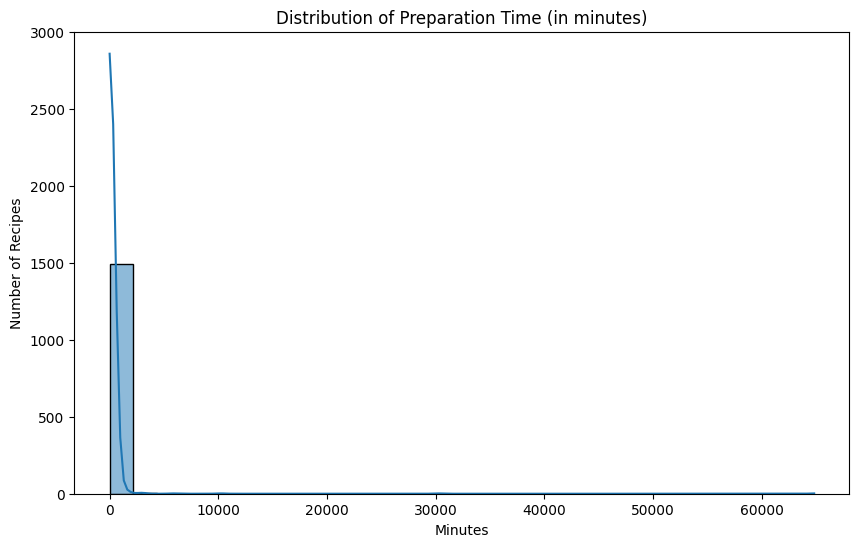

In [ ]:
# Distribution of recipe preparation times
plt.figure(figsize=(10, 6))
sns.histplot(recipes_df['minutes'], bins=30, kde=True)
plt.title('Distribution of Preparation Time (in minutes)')
plt.xlabel('Minutes')
plt.ylabel('Number of Recipes')
plt.show()

In [ ]:
recipes_df.describe()

,minutes,n_steps,n_ingredients
count,1500.0000,1500.000000,1500.000000
mean,153.7820,10.110000,9.041333
std,1877.8289,6.188007,3.720150
min,0.0000,1.000000,2.000000
25%,20.0000,6.000000,6.000000
50%,40.0000,9.000000,9.000000
75%,70.0000,13.000000,11.000000
max,64815.0000,50.000000,25.000000


<ipython-input-18-9c9355c93c9d>:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(y=most_common_ingredients.index, x=most_common_ingredients.values, palette='viridis')


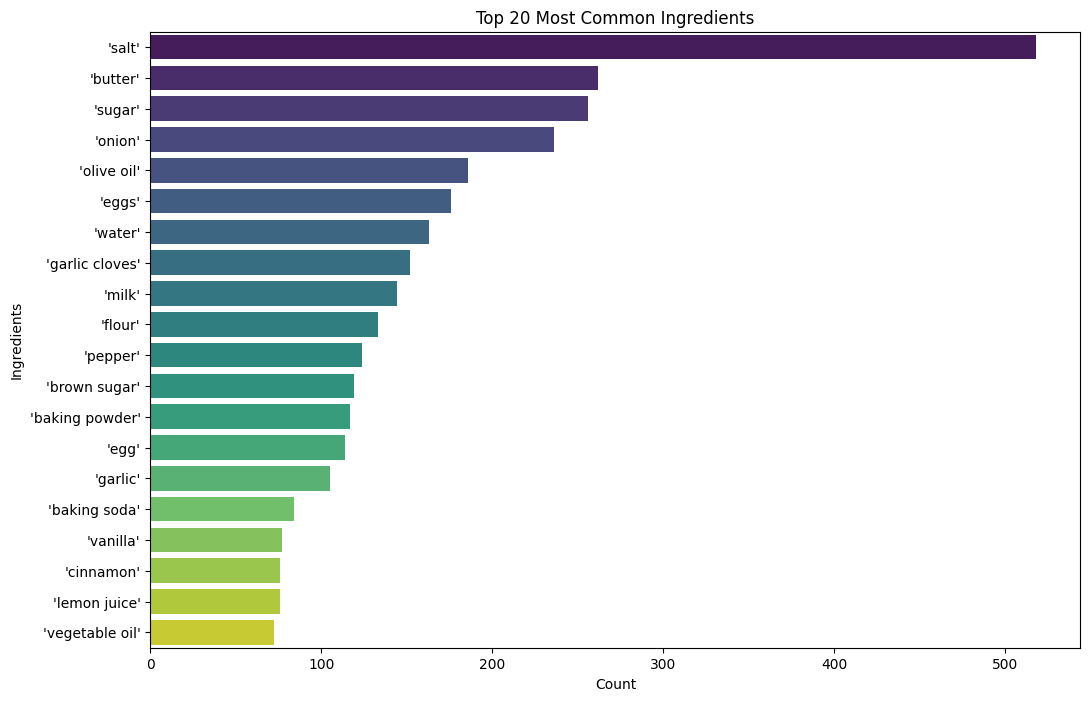

In [ ]:
# Most common ingredients
all_ingredients = ' '.join(recipes_df['ingredients']).split(', ')
most_common_ingredients = pd.Series(all_ingredients).value_counts().head(20)

plt.figure(figsize=(12, 8))
sns.barplot(y=most_common_ingredients.index, x=most_common_ingredients.values, palette='viridis')
plt.title('Top 20 Most Common Ingredients')
plt.xlabel('Count')
plt.ylabel('Ingredients')
plt.show()

In [ ]:
# Convert all text to lowercase
recipes_df['ingredients'] = recipes_df['ingredients'].str.lower()
recipes_df['tags'] = recipes_df['tags'].str.lower()
recipes_df['description'] = recipes_df['description'].str.lower()

# Function to remove punctuation
def remove_punctuation(text):
    return text.translate(str.maketrans('', '', string.punctuation))

# Apply punctuation removal
recipes_df['ingredients_cleaned'] = recipes_df['ingredients'].apply(remove_punctuation)
recipes_df['tags_cleaned'] = recipes_df['tags'].apply(remove_punctuation)
recipes_df['description_cleaned'] = recipes_df['description'].apply(remove_punctuation)

In [ ]:
# Initialize stop words
stop_words = set(nltk.corpus.stopwords.words('english'))

# Function to remove stop words
def remove_stop_words(text):
    tokens = nltk.word_tokenize(text)
    filtered_tokens = [word for word in tokens if word.lower() not in stop_words]
    return ' '.join(filtered_tokens)

# Apply stop words removal
recipes_df['ingredients_cleaned'] = recipes_df['ingredients_cleaned'].apply(remove_stop_words)
recipes_df['tags_cleaned'] = recipes_df['tags_cleaned'].apply(remove_stop_words)
recipes_df['description_cleaned'] = recipes_df['description_cleaned'].apply(remove_stop_words)

In [ ]:
# Initialize the stemmer
stemmer = nltk.PorterStemmer()

# Function to apply stemming
def stem_text(text):
    tokens = nltk.word_tokenize(text)
    stemmed_tokens = [stemmer.stem(word) for word in tokens]
    return ' '.join(stemmed_tokens)

# Apply stemming
recipes_df['ingredients_stemmed'] = recipes_df['ingredients_cleaned'].apply(stem_text)
recipes_df['tags_stemmed'] = recipes_df['tags_cleaned'].apply(stem_text)
recipes_df['description_stemmed'] = recipes_df['description_cleaned'].apply(stem_text)

In [ ]:
# Initialize the lemmatizer
lemmatizer = nltk.WordNetLemmatizer()

# Function to apply lemmatization
def lemmatize_text(text):
    tokens = nltk.word_tokenize(text)
    lemmatized_tokens = [lemmatizer.lemmatize(word) for word in tokens]
    return ' '.join(lemmatized_tokens)

# Apply lemmatization
recipes_df['ingredients_lemmatized'] = recipes_df['ingredients_stemmed'].apply(lemmatize_text)
recipes_df['tags_lemmatized'] = recipes_df['tags_stemmed'].apply(lemmatize_text)
recipes_df['description_lemmatized'] = recipes_df['description_stemmed'].apply(lemmatize_text)

In [ ]:
# Combine cleaned, stemmed, and lemmatized columns into a "soup"
recipes_df['soup'] = recipes_df['tags_lemmatized'] + ' ' + recipes_df['ingredients_lemmatized'] + ' ' + recipes_df['description_lemmatized']

In [ ]:
# Initialize TF-IDF Vectorizer
tfidf = TfidfVectorizer(stop_words='english')

# Fit and transform the "soup" column
tfidf_matrix = tfidf.fit_transform(recipes_df['soup'])

In [ ]:
# # Compute cosine similarity matrix

# # Define batch size
# batch_size = 100

# # Initialize cosine similarity matrix
# cosine_sim = np.zeros((tfidf_matrix.shape[0], tfidf_matrix.shape[0]))

# # Compute cosine similarity in batches
# for start in range(0, tfidf_matrix.shape[0], batch_size):
#     end = min(start + batch_size, tfidf_matrix.shape[0])
#     batch = tfidf_matrix[start:end]
#     cosine_sim[start:end] = linear_kernel(batch, tfidf_matrix)

In [ ]:
# Ensure the cosine similarity is computed correctly in batches
cosine_sim = linear_kernel(tfidf_matrix, tfidf_matrix)

# Save models, cosine similarity, and DataFrame
joblib.dump(tfidf, '/content/drive/MyDrive/ml_Store/tfidf_vectorizer.pkl')
joblib.dump(cosine_sim, '/content/drive/MyDrive/ml_Store/cosine_similarity.pkl')
recipes_df.to_pickle('/content/drive/MyDrive/ml_Store/recipes_df.pkl')

print("Model and vectorizer saved successfully!")

Model and vectorizer saved successfully!


In [ ]:
# Save the TF-IDF vectorizer
joblib.dump(tfidf, 'tfidf_vectorizer.pkl')

# Save the cosine similarity matrix
joblib.dump(cosine_sim, 'cosine_similarity.pkl')

# Save the DataFrame with the soup and indices
recipes_df.to_pickle('recipes_df.pkl')

print("Model and vectorizer saved successfully!")

Model and vectorizer saved successfully!


In [ ]:

# Save the TF-IDF vectorizer
joblib.dump(tfidf, '/content/drive/MyDrive/ml_Store/tfidf_vectorizer.pkl')

# Save the cosine similarity matrix
joblib.dump(cosine_sim, '/content/drive/MyDrive/ml_Store/cosine_similarity.pkl')

# Save the DataFrame with the soup and indices
recipes_df.to_pickle('/content/drive/MyDrive/ml_Store/recipes_df.pkl')

print("Model and vectorizer saved successfully!")

Model and vectorizer saved successfully!


In [ ]:
# Save the model with gzip compression
joblib.dump(model, 'model_rf.joblib.gz', compress=('gzip', 3))  # '3' is the compression level

# Save the model with bz2 compression
joblib.dump(model, 'model_rf.joblib.bz2', compress=('bz2', 3))  # '3' is the compression level

NameError: name 'model' is not defined

In [ ]:
# Create indices mapping from recipe name to DataFrame index
indices = pd.Series(recipes_df.index, index=recipes_df['name']).drop_duplicates()

def get_recommendations(name, cosine_sim=cosine_sim):
    # Get the index of the recipe that matches the name
    idx = indices[name]

    # Get the pairwise similarity scores of all recipes with that recipe
    sim_scores = list(enumerate(cosine_sim[idx]))

    # Sort the recipes based on the similarity scores
    sim_scores = sorted(sim_scores, key=lambda x: x[1], reverse=True)

    # Get the scores of the 10 most similar recipes
    sim_scores = sim_scores[1:11]

    # Get the recipe indices
    recipe_indices = [i[0] for i in sim_scores]

    # Return the top 10 most similar recipes
    return recipes_df[['name', 'ingredients', 'minutes', 'steps', 'tags']].iloc[recipe_indices]

In [ ]:
get_recommendations('double shot mocha chunk cookies')

In [ ]:
get_recommendations('chocolate chocolate chunk muffins')

In [ ]:
get_recommendations('wonderful chocolate pound cake')

In [ ]:
recipes_df.to_csv('/content/drive/MyDrive/ml_Store/meal_plan_data.csv', index=False)

In [ ]:
pip install fuzzywuzzy[speedup]

In [ ]:
import pandas as pd
import numpy as np
from fuzzywuzzy import fuzz
from itertools import combinations

# Constants
FUZZY_THRESHOLD = 45  # Adjust as needed
TOP_N_RECOMMENDATIONS = 10

# Functions for recommendations and evaluation metrics

def get_recommendations(recipe_name, cosine_sim, recipes_df, top_n=TOP_N_RECOMMENDATIONS):
    """
    Get top N recipe recommendations based on cosine similarity.
    """
    try:
        idx = recipes_df.index[recipes_df['name'].str.lower() == recipe_name.lower()].tolist()[0]
    except IndexError:
        raise ValueError(f"Recipe '{recipe_name}' not found in the dataset.")

    sim_scores = list(enumerate(cosine_sim[idx]))
    sim_scores = sorted(sim_scores, key=lambda x: x[1], reverse=True)
    sim_scores = sim_scores[1:top_n+1]  # Skip the first since it's the same recipe
    recipe_indices = [i[0] for i in sim_scores]
    recommended_recipes = recipes_df['name'].iloc[recipe_indices].tolist()

    # Debugging statement
    print(f"Recommended recipes for '{recipe_name}': {recommended_recipes}")

    return recommended_recipes

def fuzzy_match(recipe, relevant_recipes):
    """
    Helper function to check if a recipe matches any of the relevant recipes using fuzzy matching.
    """
    return any(fuzz.partial_ratio(recipe.lower(), relevant.lower()) >= FUZZY_THRESHOLD for relevant in relevant_recipes)

def precision_at_k(recommended_recipes, relevant_recipes, k=TOP_N_RECOMMENDATIONS):
    recommended_at_k = recommended_recipes[:k]
    relevant_count = sum(fuzzy_match(recipe, relevant_recipes) for recipe in recommended_at_k)
    return relevant_count / k

def recall_at_k(recommended_recipes, relevant_recipes, k=TOP_N_RECOMMENDATIONS):
    recommended_at_k = recommended_recipes[:k]
    relevant_count = sum(fuzzy_match(recipe, relevant_recipes) for recipe in recommended_at_k)
    return relevant_count / len(relevant_recipes) if len(relevant_recipes) > 0 else 0

def average_precision(recommended_recipes, relevant_recipes):
    hits = 0
    sum_precisions = 0
    for i, recipe in enumerate(recommended_recipes):
        if fuzzy_match(recipe, relevant_recipes):
            hits += 1
            sum_precisions += hits / (i + 1)
    return sum_precisions / len(relevant_recipes) if len(relevant_recipes) > 0 else 0

def mean_average_precision(recommendations_list, relevant_recipes_list):
    aps = [average_precision(recommendations, relevant) for recommendations, relevant in zip(recommendations_list, relevant_recipes_list)]
    return np.mean(aps) if aps else 0

def reciprocal_rank(recommended_recipes, relevant_recipes):
    for i, recipe in enumerate(recommended_recipes):
        if fuzzy_match(recipe, relevant_recipes):
            return 1 / (i + 1)
    return 0

def mean_reciprocal_rank(recommendations_list, relevant_recipes_list):
    rr_scores = [reciprocal_rank(recommendations, relevant) for recommendations, relevant in zip(recommendations_list, relevant_recipes_list)]
    return np.mean(rr_scores) if rr_scores else 0

def coverage(recommended_recipes_list, all_recipes):
    recommended_unique = set()
    for recommendations in recommended_recipes_list:
        recommended_unique.update(recommendations)
    return len(recommended_unique) / len(all_recipes) if all_recipes else 0

def diversity(recommended_recipes, cosine_sim_matrix, recipes_df):
    if len(recommended_recipes) <= 1:
        return 0

    diversity_sum = 0
    recipe_indices = [recipes_df.index[recipes_df['name'].str.lower() == recipe.lower()][0] for recipe in recommended_recipes]

    for pair in combinations(recipe_indices, 2):
        sim_score = cosine_sim_matrix[pair[0], pair[1]]
        diversity_sum += 1 - sim_score

    num_combinations = len(list(combinations(recipe_indices, 2)))
    return diversity_sum / num_combinations if num_combinations > 0 else 0

def serendipity(recommended_recipes, relevant_recipes, popular_recipes):
    unexpected_count = sum(1 for recipe in recommended_recipes if recipe not in popular_recipes)
    relevant_unexpected = sum(1 for recipe in recommended_recipes if recipe in relevant_recipes and recipe not in popular_recipes)
    return relevant_unexpected / unexpected_count if unexpected_count > 0 else 0

# Example Usage

# Define a sample relevant recipe list for evaluation
relevant_recipes = ['spinach mushroom rotolo', 'vegetable lasagna with white sauce']

# Define a sample popular recipes list for serendipity evaluation
popular_recipes = ['ultra quick lasagna', 'spinach mushroom rotolo']

# Get recommendations for a test recipe
recommended_recipes = get_recommendations('spinach mushroom rotolo', cosine_sim, recipes_df)

# Print evaluation metrics
# Print evaluation metrics that performed well
print("Precision@K:", precision_at_k(recommended_recipes, relevant_recipes))
print("Mean Average Precision (MAP):", mean_average_precision([recommended_recipes], [relevant_recipes]))
print("Mean Reciprocal Rank (MRR):", mean_reciprocal_rank([recommended_recipes], [relevant_recipes]))

In [ ]:
import joblib

# Save model with gzip compression
joblib.dump(tfidf, '/content/drive/MyDrive/ml_Store/tfidf_vectorizer.pkl.gz', compress=('gzip', 3))

# Save model with bz2 compression
joblib.dump(cosine_sim, '/content/drive/MyDrive/ml_Store/cosine_similarity.pkl.bz2', compress=('bz2', 3))

# Load model with gzip compression
tfidf_loaded_gz = joblib.load('/content/drive/MyDrive/ml_Store/tfidf_vectorizer.pkl.gz')

# Load model with bz2 compression
cosine_sim_loaded_bz2 = joblib.load('/content/drive/MyDrive/ml_Store/cosine_similarity.pkl.bz2')